# 10 - Brent-Only Baseline Comparison

Purpose:
- Build the simplest possible alarm: a return/volatility z-score on Brent itself, using the
  same logic as Gold's own-behaviour signal in Step 04, but with nothing else feeding into
  it.
- Run this Brent-only alarm through the same lead-time and false-alarm tests as Notebook 09.
- Compare it side by side with the Gold alarm, to see what (if anything) Gold adds beyond
  what the risk book already knows about Brent itself.

Core framing:
If a simple "watch Brent" rule performs about as well as the Gold alarm, Gold isn't adding
much. If the Gold alarm catches more events, has fewer false alarms, or gives more lead
time, that's evidence the dashboard is worth having.

## Reader Orientation

This notebook answers a question from group discussion: "what if we just watched Brent
itself?" We build the simplest possible early-warning rule - a trailing z-score on Brent's
own return and volatility - and run it through the same lead-time and false-alarm tests as
Notebook 09. The Gold alarm only earns its keep if it does better than this naive baseline.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step10_brent_baseline_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

dashboard_path = ROOT / "outputs" / "step09_lead_time_dashboard" / "dashboard_metrics.csv"

market_vars = pd.read_parquet(market_vars_path)
dashboard = pd.read_csv(dashboard_path, index_col=0, parse_dates=True)

required_cols = ["var_breach", "portfolio_vol_spike", "drawdown", "cooled_gold_alarm"]
missing_cols = [col for col in required_cols if col not in dashboard.columns]
if missing_cols:
    raise ValueError(f"Missing expected Notebook 09 columns: {missing_cols}")

data = market_vars[["r_Brent"]].join(dashboard, how="inner")

print("Loaded:", market_vars_path)
print("Loaded:", dashboard_path)
print("Shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())
data.tail()

Loaded: C:\Users\shrut\OneDrive - Singapore Management University\SMU Master's in Quantitative Finance\Sem3\QF637 Commodities Risk Management\Commonds Projects\qf637\data\processed\market_vars_core.parquet
Loaded: C:\Users\shrut\OneDrive - Singapore Management University\SMU Master's in Quantitative Finance\Sem3\QF637 Commodities Risk Management\Commonds Projects\qf637\outputs\step06\dashboard_metrics.csv
Shape: (4096, 15)
Date range: 2010-01-05 00:00:00 to 2026-06-09 00:00:00


,r_Brent,R_book,nav,drawdown,hs_var_return,hs_es_return,var_breach,realized_vol_20d,portfolio_vol_z,portfolio_vol_spike,gold_alarm,cooled_gold_alarm,alarm_score,dashboard_state,recommended_action
Date,,,,,,,,,,,,,,,
2026-06-03,0.018679,0.018679,39.467602,-0.738760,-0.044967,-0.08652,0,0.523871,0.403566,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-06-04,-0.028834,-0.028834,38.329587,-0.746292,-0.044967,-0.08652,0,0.451262,0.115876,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-06-05,-0.020626,-0.020626,37.539005,-0.751525,-0.044967,-0.08652,0,0.454520,0.125558,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-06-08,0.012384,0.012384,38.003891,-0.748448,-0.044967,-0.08652,0,0.454597,0.122533,0,0,0,1,Amber,Monitor and inspect gold relationship components
2026-06-09,-0.020582,-0.020582,37.221707,-0.753625,-0.044967,-0.08652,0,0.441916,0.069339,0,1,1,2,Red,Run stress tests and review VaR calibration


In [3]:
BASELINE_WIN = 252
VOL_WIN = 30
THRESHOLD = 2.0
COOLDOWN_DAYS = 5
LOOKBACK_DAYS = 30
DRAWDOWN_EVENT_LEVEL = -0.05

## Helper Functions

These are the same trailing z-score, cooldown, event-start, and lead-matching helpers from
Steps 04 and 06, copied here so this notebook can run on its own. Using identical logic is
what keeps the Gold-vs-Brent comparison fair. Two small wrappers
(`lead_summary_table`, `false_alarm_table_and_summary`) let us run the same tests on both
the Brent baseline and the Gold alarm without repeating the code.

In [4]:
def trailing_zscore(series: pd.Series, window: int = BASELINE_WIN) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


def apply_cooldown(flag: pd.Series, cooldown_days: int) -> pd.Series:
    cooled = pd.Series(0, index=flag.index, dtype=int)
    last_fire = None
    for date, value in flag.fillna(0).astype(int).items():
        if value != 1:
            continue
        if last_fire is None or (date - last_fire).days > cooldown_days:
            cooled.loc[date] = 1
            last_fire = date
    return cooled


def match_leads(alarm_dates: pd.DatetimeIndex, event_dates: pd.DatetimeIndex, lookback_days: int) -> pd.DataFrame:
    rows = []
    for event_date in event_dates:
        candidates = alarm_dates[
            (alarm_dates <= event_date)
            & (alarm_dates >= event_date - pd.Timedelta(days=lookback_days))
        ]
        if len(candidates) == 0:
            rows.append({
                "event_date": event_date,
                "matched": False,
                "alarm_date": pd.NaT,
                "lead_days": np.nan,
            })
        else:
            alarm_date = candidates[-1]
            rows.append({
                "event_date": event_date,
                "matched": True,
                "alarm_date": alarm_date,
                "lead_days": (event_date - alarm_date).days,
            })
    return pd.DataFrame(rows)


def lead_summary_table(alarm_dates, event_families, lookback_days):
    tables = []
    for family, dates in event_families.items():
        table = match_leads(alarm_dates, dates, lookback_days)
        table["event_family"] = family
        tables.append(table)
    lead_table = pd.concat(tables, ignore_index=True)
    summary = (
        lead_table
        .groupby("event_family")
        .agg(
            event_count=("event_date", "count"),
            matched_count=("matched", "sum"),
            match_rate=("matched", "mean"),
            avg_lead_days=("lead_days", "mean"),
            median_lead_days=("lead_days", "median"),
        )
        .reset_index()
    )
    return lead_table, summary


def false_alarm_table_and_summary(alarm_dates, all_event_dates, lookback_days):
    rows = []
    for alarm_date in alarm_dates:
        future_events = all_event_dates[
            (all_event_dates >= alarm_date)
            & (all_event_dates <= alarm_date + pd.Timedelta(days=lookback_days))
        ]
        rows.append({
            "alarm_date": alarm_date,
            "followed_by_event": len(future_events) > 0,
            "next_event_date": future_events[0] if len(future_events) else pd.NaT,
        })
    table = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "alarm_count": len(table),
        "false_alarm_count": int((~table["followed_by_event"]).sum()) if len(table) else 0,
        "false_alarm_rate": float((~table["followed_by_event"]).mean()) if len(table) else np.nan,
    }])
    return table, summary

## Define Risk Events (Same As Notebook 09)

We use the same three risk events as Notebook 09: VaR breaches, portfolio volatility spikes, and
drawdown breaches, all sourced from `dashboard_metrics.csv`. Using the exact same
definitions keeps the Brent and Gold comparisons on the same footing.

In [5]:
event_families = {
    "var_breach": event_starts(data["var_breach"]),
    "portfolio_vol_spike": event_starts(data["portfolio_vol_spike"]),
    "drawdown_event": event_starts((data["drawdown"] <= DRAWDOWN_EVENT_LEVEL).astype(int)),
}

all_event_dates = pd.DatetimeIndex(
    sorted(set().union(*[set(dates) for dates in event_families.values()]))
)

for family, dates in event_families.items():
    print(family, len(dates))
print("all_event_dates (union):", len(all_event_dates))

var_breach 198
portfolio_vol_spike 21
drawdown_event 15
all_event_dates (union): 220


## Brent-Only Baseline Alarm

This mirrors Gold's "own behaviour" signal from Step 04: a trailing return z-score and a
trailing volatility z-score, both checked against the same 2.0 threshold - but applied to
Brent, with nothing else feeding in. If the book were already watching Brent this closely,
this is the alarm it would be running.

In [6]:
brent_return_z = trailing_zscore(data["r_Brent"], BASELINE_WIN)
brent_vol = data["r_Brent"].rolling(VOL_WIN).std()
brent_vol_z = trailing_zscore(brent_vol, BASELINE_WIN)

baseline = pd.DataFrame(index=data.index)
baseline["brent_return_z"] = brent_return_z
baseline["brent_vol_z"] = brent_vol_z
baseline["brent_alarm"] = (
    (brent_return_z.abs() > THRESHOLD) | (brent_vol_z > THRESHOLD)
).astype(int)
baseline["cooled_brent_alarm"] = apply_cooldown(baseline["brent_alarm"], COOLDOWN_DAYS)

print("Raw Brent alarm days:", int(baseline["brent_alarm"].sum()))
print("Cooled Brent alarm starts:", int(event_starts(baseline["cooled_brent_alarm"]).shape[0]))
baseline.tail()

Raw Brent alarm days: 497
Cooled Brent alarm starts: 201


,brent_return_z,brent_vol_z,brent_alarm,cooled_brent_alarm
Date,,,,
2026-06-03,0.544668,0.612158,0,0
2026-06-04,-0.972492,0.591628,0,0
2026-06-05,-0.703944,0.560602,0,0
2026-06-08,0.348657,0.562924,0,0
2026-06-09,-0.701492,0.534526,0,0


### Result Comment And Significance

The naive Brent-only rule fires much more often than Gold's grouped alarm: 497 raw alarm
days (about 12% of the sample) before cooldown, settling to 201 cooled alarms (about 5% of
days) after the same 5-day cooldown as Notebook 09. That makes sense - a single return-or-vol
test on Brent alone is far less restrictive than Gold's requirement that 2 of 3 independent
signal families fire together.

## Lead-Time Test: Brent Baseline Vs Same Risk Events

A "match" means a cooled Brent-baseline alarm fired within the 30-day lookback before the
risk event, using the same matching logic as Notebook 09.

In [7]:
brent_alarm_dates = event_starts(baseline["cooled_brent_alarm"])

brent_lead_time_table, brent_lead_summary = lead_summary_table(
    brent_alarm_dates, event_families, LOOKBACK_DAYS
)

brent_lead_summary

,event_family,event_count,matched_count,match_rate,avg_lead_days,median_lead_days
0,drawdown_event,15,2,0.133333,0.000000,0.0
1,portfolio_vol_spike,21,21,1.000000,1.380952,1.0
2,var_breach,198,166,0.838384,2.861446,0.0


### Result Comment And Significance

The Brent-only baseline matches almost every VaR breach (84%) and every volatility spike
(100%) - but the median lead time is just 0-1 days. That makes sense: both event types are
derived directly from Brent's own returns, so a Brent z-score crossing 2.0 happens at almost
the same time as the event it's "anticipating" - it's confirming the move, not warning about
it in advance. Drawdown events are matched far less often (13%, 2 of 15), since a single
day's return/vol reading can't capture a slower-building loss.

## False-Alarm Rate: Brent Baseline

Same definition as Notebook 09: a cooled alarm is a false alarm if none of the three risk events
starts within 30 days of it.

In [8]:
brent_false_alarm_table, brent_false_alarm_summary = false_alarm_table_and_summary(
    brent_alarm_dates, all_event_dates, LOOKBACK_DAYS
)

brent_false_alarm_summary

,alarm_count,false_alarm_count,false_alarm_rate
0,201,27,0.134328


### Result Comment And Significance

The Brent-only baseline has a false-alarm rate of about 13% (27 of 201 cooled alarms), well
below Gold's 32% from Notebook 09. This follows directly from the lead-time result above: since
the baseline mostly fires in lockstep with VaR breaches and vol spikes, most of its alarms
are "confirmed" by an event in the same window almost by construction.

## Gold Alarm Vs Brent-Only Baseline

We recompute the Gold-side numbers here from `cooled_gold_alarm` (already stored in
`dashboard_metrics.csv` from Notebook 09), using the same helper functions. This keeps the
comparison apples-to-apples within this notebook, rather than relying on saved CSVs that
might drift if the data is re-pulled.

In [9]:
gold_alarm_dates = event_starts(data["cooled_gold_alarm"])

gold_lead_time_table, gold_lead_summary = lead_summary_table(
    gold_alarm_dates, event_families, LOOKBACK_DAYS
)
gold_false_alarm_table, gold_false_alarm_summary = false_alarm_table_and_summary(
    gold_alarm_dates, all_event_dates, LOOKBACK_DAYS
)

comparison_rows = []
for family in event_families:
    g = gold_lead_summary.loc[gold_lead_summary["event_family"] == family].iloc[0]
    b = brent_lead_summary.loc[brent_lead_summary["event_family"] == family].iloc[0]
    comparison_rows.append({
        "event_family": family,
        "event_count": int(g["event_count"]),
        "gold_match_rate": g["match_rate"],
        "brent_baseline_match_rate": b["match_rate"],
        "gold_avg_lead_days": g["avg_lead_days"],
        "brent_baseline_avg_lead_days": b["avg_lead_days"],
        "gold_median_lead_days": g["median_lead_days"],
        "brent_baseline_median_lead_days": b["median_lead_days"],
    })
comparison_table = pd.DataFrame(comparison_rows)

overall_comparison = pd.DataFrame([
    {
        "signal": "gold_alarm",
        "alarm_count": len(gold_alarm_dates),
        "alarm_rate": len(gold_alarm_dates) / len(data),
        "false_alarm_rate": float(gold_false_alarm_summary["false_alarm_rate"].iloc[0]),
    },
    {
        "signal": "brent_baseline",
        "alarm_count": len(brent_alarm_dates),
        "alarm_rate": len(brent_alarm_dates) / len(data),
        "false_alarm_rate": float(brent_false_alarm_summary["false_alarm_rate"].iloc[0]),
    },
])

print(comparison_table)
overall_comparison

          event_family  event_count  gold_match_rate  \
0           var_breach          198         0.606061   
1  portfolio_vol_spike           21         0.761905   
2       drawdown_event           15         0.333333   

   brent_baseline_match_rate  gold_avg_lead_days  \
0                   0.838384              8.1750   
1                   1.000000              9.4375   
2                   0.133333             12.8000   

   brent_baseline_avg_lead_days  gold_median_lead_days  \
0                      2.861446                    6.0   
1                      1.380952                    9.0   
2                      0.000000                   14.0   

   brent_baseline_median_lead_days  
0                              0.0  
1                              1.0  
2                              0.0  


,signal,alarm_count,alarm_rate,false_alarm_rate
0,gold_alarm,167,0.040771,0.323353
1,brent_baseline,201,0.049072,0.134328


### Result Comment And Significance

This comparison shows what Gold adds, and what it costs, versus a naive "watch Brent" rule:

- **Match rate**: Brent matches more VaR-breach (84% vs 61%) and vol-spike (100% vs 76%)
  episodes, but Gold matches more drawdown episodes (33% vs 13%).
- **Lead time**: this is where Gold wins. Median lead time for Gold is 6 days (VaR breach),
  9 days (vol spike), and 14 days (drawdown) - versus 0, 1, and 0 days for Brent. The Brent
  rule is mostly a same-day confirmation that stress has already hit the book; Gold tends to
  fire days ahead.
- **False alarms**: Gold's false-alarm rate (32%) is more than double Brent's (13%), even
  though both fire on a similar share of days (4-5%). That's the cost of earlier warning -
  Gold reacts to cross-market shifts that don't always lead to a Brent-book event within 30
  days.

A Brent-only rule isn't a substitute for the Gold alarm - it's a same-day confirmation tool,
not an early-warning one. Gold's value is the lead time, at the cost of more false alarms,
which Notebook 09 looks at in more detail.

## Fair Comparison: Early-Warning-Only Matching

The match rates above count any alarm within 30 days of an event as a "match" - including
alarms that fire on the *same day* as the event. For the Brent baseline, that's doing a lot
of work: a large Brent return/vol move is mechanically almost the same thing as a VaR
breach, so many of its "matches" are same-day coincidences, not advance warnings.

To compare early-warning value fairly, this section only counts a "genuine" catch as one
that fired strictly *before* the event (`lead_days >= 1`). It then asks: of all the
VaR-at-risk on `var_breach` days, how much was actually flagged in advance by each signal,
versus only confirmed same-day or missed entirely?

In [10]:
def match_rate_min_lead(lead_table, min_lead):
    matched_ge = lead_table["matched"] & (lead_table["lead_days"] >= min_lead)
    return matched_ge.groupby(lead_table["event_family"]).mean()


gold_rate_lead_ge1 = match_rate_min_lead(gold_lead_time_table, 1)
brent_rate_lead_ge1 = match_rate_min_lead(brent_lead_time_table, 1)

early_warning_comparison = comparison_table[
    ["event_family", "gold_match_rate", "brent_baseline_match_rate"]
].copy()
early_warning_comparison = early_warning_comparison.rename(columns={
    "gold_match_rate": "gold_match_rate_lead_ge0",
    "brent_baseline_match_rate": "brent_baseline_match_rate_lead_ge0",
})
early_warning_comparison["gold_match_rate_lead_ge1"] = (
    early_warning_comparison["event_family"].map(gold_rate_lead_ge1)
)
early_warning_comparison["brent_baseline_match_rate_lead_ge1"] = (
    early_warning_comparison["event_family"].map(brent_rate_lead_ge1)
)

early_warning_comparison

,event_family,gold_match_rate_lead_ge0,brent_baseline_match_rate_lead_ge0,gold_match_rate_lead_ge1,brent_baseline_match_rate_lead_ge1
0,var_breach,0.606061,0.838384,0.494949,0.378788
1,portfolio_vol_spike,0.761905,1.000000,0.619048,0.523810
2,drawdown_event,0.333333,0.133333,0.266667,0.000000


In [11]:
data["excess_loss_over_var"] = data["hs_var_return"] - data["R_book"]
excess_loss = data["excess_loss_over_var"]


def lead_bucket(row):
    if not row["matched"]:
        return "not_caught"
    if row["lead_days"] == 0:
        return "same_day"
    if row["lead_days"] <= 4:
        return "early_warning_1_4d"
    return "early_warning_ge5d"


bucket_order = ["not_caught", "same_day", "early_warning_1_4d", "early_warning_ge5d"]

var_risk_rows = []
for label, lead_table in [("gold_alarm", gold_lead_time_table), ("brent_baseline", brent_lead_time_table)]:
    sub = lead_table[lead_table["event_family"] == "var_breach"].copy()
    sub["excess_loss_over_var"] = sub["event_date"].map(excess_loss)
    sub["lead_bucket"] = sub.apply(lead_bucket, axis=1)
    total = sub["excess_loss_over_var"].sum()
    grouped = sub.groupby("lead_bucket")["excess_loss_over_var"].sum()
    for bucket in bucket_order:
        var_risk_rows.append({
            "signal": label,
            "lead_bucket": bucket,
            "var_risk_sum": grouped.get(bucket, 0.0),
            "pct_of_total_var_risk": grouped.get(bucket, 0.0) / total * 100,
        })

var_risk_coverage = pd.DataFrame(var_risk_rows)
var_risk_coverage_pivot = var_risk_coverage.pivot(
    index="lead_bucket", columns="signal", values="pct_of_total_var_risk"
).reindex(bucket_order)

genuine_warning_summary = pd.DataFrame([
    {
        "signal": "gold_alarm",
        "pct_var_risk_lead_ge1": var_risk_coverage_pivot.loc[
            ["early_warning_1_4d", "early_warning_ge5d"], "gold_alarm"
        ].sum(),
    },
    {
        "signal": "brent_baseline",
        "pct_var_risk_lead_ge1": var_risk_coverage_pivot.loc[
            ["early_warning_1_4d", "early_warning_ge5d"], "brent_baseline"
        ].sum(),
    },
])

print(var_risk_coverage_pivot)
genuine_warning_summary

signal              brent_baseline  gold_alarm
lead_bucket                                   
not_caught                4.135143   29.815223
same_day                 57.330900   15.374834
early_warning_1_4d       32.550515   19.214241
early_warning_ge5d        5.983442   35.595703


,signal,pct_var_risk_lead_ge1
0,gold_alarm,54.809944
1,brent_baseline,38.533957


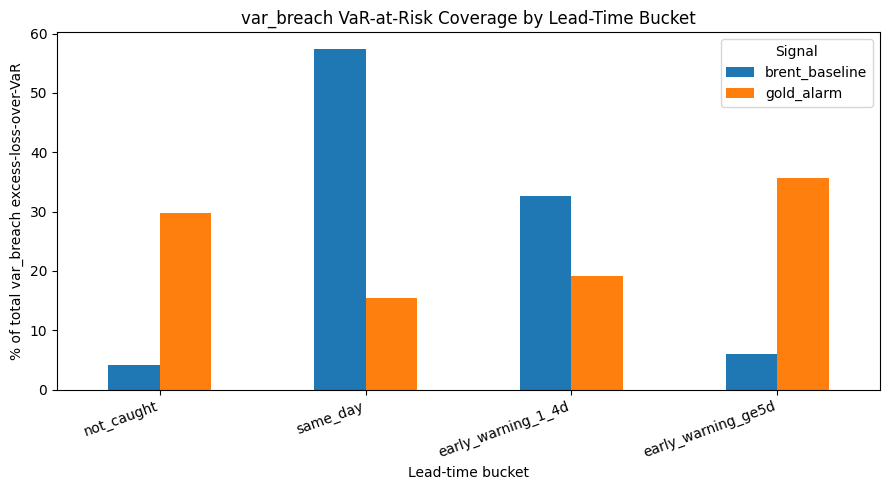

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
var_risk_coverage_pivot.plot(kind="bar", ax=ax)
ax.set_title("var_breach VaR-at-Risk Coverage by Lead-Time Bucket")
ax.set_ylabel("% of total var_breach excess-loss-over-VaR")
ax.set_xlabel("Lead-time bucket")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Signal")
plt.tight_layout()
plt.show()

### Result Comment And Significance

Once same-day matches are excluded (`lead_days >= 1`), the picture flips for every event
family:

| Event family | Gold (any match / 1+ day lead) | Brent baseline (any match / 1+ day lead) |
|---|---|---|
| var_breach | 61% / **50%** | 84% / **38%** |
| portfolio_vol_spike | 76% / **62%** | 100% / **52%** |
| drawdown_event | 33% / **27%** | 13% / **0%** |

Brent's apparent edge on var_breach and vol_spike mostly disappears once same-day matches
don't count - and for drawdown events it vanishes completely. Brent has never flagged a
drawdown with any lead time; every "match" was same-day or no match at all.

The VaR-at-risk view tells the same story in dollar terms. Looking at all the losses on
var_breach days:

- **Brent baseline**: 57% of that risk is only confirmed same-day, 4% is missed entirely,
  and just 39% comes with any advance notice.
- **Gold alarm**: 30% is missed, 15% is same-day, and **55%** comes with advance notice -
  and over a third of all the risk (36%) gets 5+ days of warning, versus just 6% for Brent.

So while Brent appeared to "cover" 96% of var_breach risk in the simple comparison, most of
that (57 points) was zero-lead confirmation - it noticed the loss as it happened, not
before. On a like-for-like, advance-notice basis, Gold covers more of the risk the book is
actually exposed to (55% vs 39%), even though it matches fewer raw events. That's the fair
comparison: Brent is essentially a coincident indicator, while Gold's cross-market signal is
the one that actually buys the desk time to act.

## Brent Baseline Signal Plot

Plotting Brent's return and volatility z-scores against the same +/-2.0 threshold from Step
04 shows how often a Brent-only rule would fire on its own.

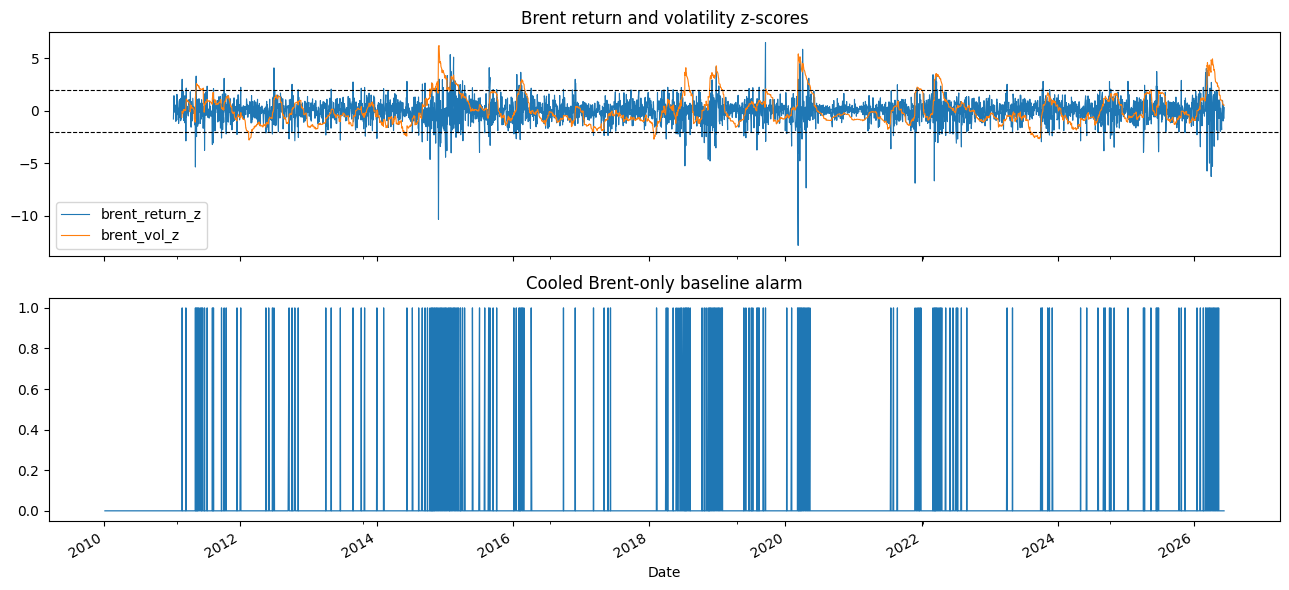

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

baseline[["brent_return_z", "brent_vol_z"]].plot(ax=axes[0], linewidth=0.8)
axes[0].axhline(THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[0].axhline(-THRESHOLD, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Brent return and volatility z-scores")

baseline["cooled_brent_alarm"].plot(ax=axes[1], linewidth=0.9)
axes[1].set_title("Cooled Brent-only baseline alarm")

plt.tight_layout()

## Notebook 10 Working Takeaways

- **A naive "watch Brent" alarm isn't a substitute for the Gold alarm.** It matches more
  VaR-breach and vol-spike events, but almost always without lead time (median 0-1 days),
  because its alarm condition is mechanically tied to the same Brent returns that define
  those events.
- **Gold trades a lower match rate and more false alarms (32% vs 13%) for much longer lead
  times** (median 6-14 days vs 0-1 days) - that's the core early-warning value proposition.
- **Gold also beats Brent on drawdown events** (33% vs 13% match rate), suggesting
  cross-market relationship signals pick up slower-building stress that Brent's own
  short-window stats miss.
- **Once same-day coincidences are excluded, Gold gives genuine early warning more often
  than Brent across all three event families** (var_breach 50% vs 38%, vol_spike 62% vs
  52%, drawdown 27% vs 0%), and covers 55% of total var_breach risk with advance notice
  versus Brent's 39%. Brent's headline 96% "coverage" was mostly same-day confirmation, not
  foresight.
- This sets up Notebook 08 (which misses are shared vs unique to each signal) and Notebook
  09 (whether Gold's higher false-alarm rate still carries useful information).

In [14]:
baseline.to_parquet(PROCESSED_DIR / "brent_baseline_alarm.parquet")

brent_lead_time_table.to_csv(OUTPUT_DIR / "brent_baseline_lead_time_table.csv", index=False)
brent_lead_summary.to_csv(OUTPUT_DIR / "brent_baseline_lead_time_summary.csv", index=False)
brent_false_alarm_table.to_csv(OUTPUT_DIR / "brent_baseline_false_alarm_table.csv", index=False)
brent_false_alarm_summary.to_csv(OUTPUT_DIR / "brent_baseline_false_alarm_summary.csv", index=False)
comparison_table.to_csv(OUTPUT_DIR / "baseline_vs_gold_comparison.csv", index=False)
overall_comparison.to_csv(OUTPUT_DIR / "baseline_vs_gold_overall.csv", index=False)

print("Saved Step 10 Brent-baseline outputs to:", OUTPUT_DIR)
print("Brent baseline alarm frame:", PROCESSED_DIR / "brent_baseline_alarm.parquet")

early_warning_comparison.to_csv(OUTPUT_DIR / "early_warning_match_rate_comparison.csv", index=False)
var_risk_coverage_pivot.to_csv(OUTPUT_DIR / "var_breach_var_risk_coverage_by_lead_bucket.csv")

Saved Step 07 Brent-baseline outputs to: C:\Users\shrut\OneDrive - Singapore Management University\SMU Master's in Quantitative Finance\Sem3\QF637 Commodities Risk Management\Commonds Projects\qf637\outputs\step07
Brent baseline alarm frame: C:\Users\shrut\OneDrive - Singapore Management University\SMU Master's in Quantitative Finance\Sem3\QF637 Commodities Risk Management\Commonds Projects\qf637\data\processed\brent_baseline_alarm.parquet
